<a href="https://colab.research.google.com/github/ArulKingsley/SmartQuant/blob/naveen-dev/openlab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q stable-baselines3[extra] sb3-contrib gymnasium shimmy
!pip install -q yfinance torch tqdm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 10.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings, os, json, copy
from tqdm import tqdm

warnings.filterwarnings('ignore')
import yfinance as yf
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from sb3_contrib import RecurrentPPO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)

TRAIN_STOCKS = ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM', 'AMZN', 'BAC', 'NVDA']
TEST_STOCKS  = ['GOOGL', 'PFE', 'GS', 'CVX', 'WMT', 'UNH']

REGIME_PERIODS = {
    'bear': [
        ('2007-10-01', '2009-03-31'),
        ('2011-07-01', '2011-10-31'),
        ('2018-10-01', '2018-12-31'),
        ('2020-02-01', '2020-03-31'),
        ('2022-01-01', '2022-10-31'),
    ],
    'bull': [
        ('2009-04-01', '2011-06-30'),
        ('2012-01-01', '2015-07-31'),
        ('2016-03-01', '2018-09-30'),
        ('2020-04-01', '2021-12-31'),
        ('2023-01-01', '2024-01-01'),
    ],
    'volatile': [
        ('2010-04-01', '2010-12-31'),
        ('2015-08-01', '2016-02-28'),
        ('2019-08-01', '2019-12-31'),
        ('2021-11-01', '2022-01-31'),
        ('2023-03-01', '2023-09-30'),
    ],
}

FEATURE_COLS  = ['return_1d','return_5d','return_20d','rsi','macd',
                 'macd_signal','macd_hist','bb_pct','atr_pct','volume_norm']
OBS_DIM       = len(FEATURE_COLS) + 2   # 12
LATENT_DIM    = 16
CONTEXT_STEPS = 60
TRADE_STEPS   = 64
EPISODE_LEN   = CONTEXT_STEPS + TRADE_STEPS

print(f"OBS_DIM={OBS_DIM}  LATENT_DIM={LATENT_DIM}")
print(f"Context={CONTEXT_STEPS}  Trade={TRADE_STEPS}  Total={EPISODE_LEN}")


Device: cuda
OBS_DIM=12  LATENT_DIM=16
Context=60  Trade=64  Total=124


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
def _add_features(df):
    df = df.copy(); close = df['Close']; vol = df['Volume']
    df['return_1d']  = close.pct_change(1)
    df['return_5d']  = close.pct_change(5)
    df['return_20d'] = close.pct_change(20)
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta).clip(lower=0).rolling(14).mean()
    rs    = gain / (loss + 1e-8)
    df['rsi'] = (100 - 100 / (1 + rs)) / 100 - 0.5
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26; sig = macd.ewm(span=9, adjust=False).mean()
    df['macd']        = macd / close
    df['macd_signal'] = sig  / close
    df['macd_hist']   = (macd - sig) / close
    ma20  = close.rolling(20).mean(); std20 = close.rolling(20).std()
    df['bb_pct'] = (close - (ma20 - 2*std20)) / (4*std20 + 1e-8) - 0.5
    hl  = df['High'] - df['Low']
    hc  = (df['High'] - close.shift(1)).abs()
    lc  = (df['Low']  - close.shift(1)).abs()
    atr = pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(14).mean()
    df['atr_pct']     = atr / close
    vol_ma = vol.rolling(20).mean()
    df['volume_norm'] = ((vol / (vol_ma + 1e-8)) - 1).clip(-3, 3)
    return df.replace([np.inf, -np.inf], np.nan).ffill().fillna(0)

def download_stocks(tickers, start='2006-01-01', end='2024-01-01'):
    data = {}
    for t in tickers:
        try:
            raw = yf.download(t, start=start, end=end, auto_adjust=True, progress=False)
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            if len(raw) > 300:
                data[t] = _add_features(raw)
                print(f"  ok {t}: {len(data[t])} days")
        except Exception as e:
            print(f"  fail {t}: {e}")
    return data

print("Downloading 2006-2024 ...")
all_data   = download_stocks(TRAIN_STOCKS + TEST_STOCKS)
train_data = {t: all_data[t] for t in TRAIN_STOCKS if t in all_data}
test_data  = {t: all_data[t] for t in TEST_STOCKS  if t in all_data}
print(f"Train: {list(train_data.keys())}")
print(f"Test:  {list(test_data.keys())}")


  ok AAPL: 4529 days


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  ok MSFT: 4529 days


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  ok JPM: 4529 days


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  ok CVX: 4529 days


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  ok WMT: 4529 days
  ok UNH: 4529 days
Train: ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM', 'AMZN', 'BAC', 'NVDA']
Test:  ['GOOGL', 'PFE', 'GS', 'CVX', 'WMT', 'UNH']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
def get_regime_slices(stock_dict, regime_type, min_len=EPISODE_LEN + 1):
    slices = []
    for ticker, df in stock_dict.items():
        for s, e in REGIME_PERIODS.get(regime_type, []):
            mask = (df.index >= s) & (df.index <= e)
            sl   = df[mask]
            if len(sl) >= min_len:
                slices.append((ticker, sl.copy(), regime_type))
    return slices

print("Building regime slices ...")
train_regimes, test_regimes = {}, {}
for rtype in ['bull', 'bear', 'volatile']:
    train_regimes[rtype] = get_regime_slices(train_data, rtype)
    test_regimes[rtype]  = get_regime_slices(test_data,  rtype)
    print(f"  {rtype}: train={len(train_regimes[rtype])}  test={len(test_regimes[rtype])}")


# ── Cell 5: TradingEnv ────────────────────────────────────────
class TradingEnv(gym.Env):
    metadata = {'render_modes': []}
    def __init__(self, stock_data_dict=None, fixed_df=None, fixed_ticker='FIXED',
                 episode_length=EPISODE_LEN, transaction_cost=0.001,
                 initial_balance=10_000.0, seed=None):
        super().__init__()
        assert stock_data_dict is not None or fixed_df is not None
        self.stock_data = stock_data_dict; self.fixed_df = fixed_df
        self.fixed_ticker = fixed_ticker; self.episode_length = episode_length
        self.transaction_cost = transaction_cost; self.initial_balance = initial_balance
        self.tickers = list(stock_data_dict.keys()) if stock_data_dict else []
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(OBS_DIM,), dtype=np.float32)
        self.action_space = spaces.Discrete(3)
        self.rng = np.random.RandomState(seed)
        self._rp()

    def _rp(self):
        self.current_df = self.current_ticker = None
        self.current_idx = self.step_count = 0
        self.balance = self.prev_portfolio = self.portfolio_value = self.initial_balance
        self.shares_held = 0.0

    def reset(self, seed=None, options=None):
        if seed is not None: self.rng = np.random.RandomState(seed)
        self._rp()
        if self.fixed_df is not None:
            self.current_df, self.current_ticker = self.fixed_df, self.fixed_ticker
        else:
            ticker = self.rng.choice(self.tickers); df = self.stock_data[ticker]
            min_len = self.episode_length + 1
            if len(df) < min_len: ticker = self.tickers[0]; df = self.stock_data[ticker]
            ms = max(0, len(df) - min_len); s = self.rng.randint(0, ms + 1)
            self.current_df, self.current_ticker = df.iloc[s:s+min_len].copy(), ticker
        return self._obs(), self._info()

    def _obs(self):
        row = self.current_df.iloc[self.current_idx]
        f   = [float(row.get(c, 0.0)) if np.isfinite(float(row.get(c, 0.0))) else 0.0
               for c in FEATURE_COLS]
        f  += [float(self.shares_held > 0),
               (self.portfolio_value / self.initial_balance) - 1.0]
        return np.clip(np.array(f, dtype=np.float32), -10.0, 10.0)

    def _info(self):
        row = self.current_df.iloc[self.current_idx]
        return {'ticker': self.current_ticker, 'price': float(row['Close']),
                'portfolio_value': self.portfolio_value, 'step': self.step_count,
                'atr_pct': float(row.get('atr_pct', 0.0)),
                'next_5d_return': float(self.current_df['return_5d'].iloc[
                    min(self.current_idx+5, len(self.current_df)-1)])}

    def step(self, action):
        price = float(self.current_df.iloc[self.current_idx]['Close'])
        if action == 2 and self.balance >= price:
            sh = self.balance / (price * (1 + self.transaction_cost))
            self.balance -= sh * price * (1 + self.transaction_cost)
            self.shares_held += sh
        elif action == 0 and self.shares_held > 0:
            self.balance += self.shares_held * price * (1 - self.transaction_cost)
            self.shares_held = 0.0
        self.current_idx += 1; self.step_count += 1
        np_ = float(self.current_df.iloc[self.current_idx]['Close'])
        self.portfolio_value = self.balance + self.shares_held * np_
        reward = (self.portfolio_value - self.prev_portfolio) / self.initial_balance
        self.prev_portfolio = self.portfolio_value
        done = self.step_count >= self.episode_length - 1
        return self._obs(), reward, done, False, self._info()

print("TradingEnv ready.")

Building regime slices ...
  bull: train=40  test=30
  bear: train=16  test=12
  volatile: train=24  test=18
TradingEnv ready.


In [5]:
def train_mlp_ppo(stock_data_dict, total_timesteps=30_000, seed=42):
    print("Training MLP-PPO ...")
    def _make():
        def _init(): return Monitor(TradingEnv(stock_data_dict,
                                               episode_length=EPISODE_LEN, seed=seed))
        return _init
    model = PPO("MlpPolicy", make_vec_env(_make(), n_envs=4, seed=seed),
                learning_rate=3e-4, n_steps=2048, batch_size=256, n_epochs=3,
                gamma=0.99, gae_lambda=0.95, clip_range=0.2, ent_coef=0.01,
                verbose=0, seed=seed, device=device,
                policy_kwargs=dict(net_arch=[64, 64], activation_fn=torch.nn.ReLU))
    model.learn(total_timesteps=total_timesteps, progress_bar=True)
    model.save('models/mlp_ppo')
    print("  MLP-PPO done.")
    return model

mlp_model = train_mlp_ppo(train_data)


Training MLP-PPO ...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

  MLP-PPO done.


In [6]:
def train_lstm_ppo(stock_data_dict, total_timesteps=30_000, seed=42):
    print("Training LSTM-PPO ...")
    def _make():
        def _init(): return Monitor(TradingEnv(stock_data_dict,
                                               episode_length=EPISODE_LEN, seed=seed))
        return _init
    model = RecurrentPPO("MlpLstmPolicy", make_vec_env(_make(), n_envs=4, seed=seed),
                         learning_rate=3e-4, n_steps=512, batch_size=128, n_epochs=3,
                         gamma=0.99, gae_lambda=0.95, clip_range=0.2, ent_coef=0.01,
                         verbose=0, seed=seed, device=device,
                         policy_kwargs=dict(net_arch=dict(pi=[64], vf=[64]),
                                            lstm_hidden_size=64, n_lstm_layers=1,
                                            shared_lstm=False, enable_critic_lstm=True))
    model.learn(total_timesteps=total_timesteps, progress_bar=True)
    model.save('models/lstm_ppo')
    print("  LSTM-PPO done.")
    return model

lstm_model = train_lstm_ppo(train_data)


Output()

Training LSTM-PPO ...


  LSTM-PPO done.


In [7]:
class MAMLAgent(nn.Module):
    def __init__(self, obs_dim=OBS_DIM, action_dim=3, hidden_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.Tanh(),
        )
        self.lstm   = nn.LSTM(hidden_dim, 64, num_layers=1, batch_first=True)
        self.actor  = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, action_dim))
        self.critic = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 1))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x, hidden=None):
        if x.dim() == 2: x = x.unsqueeze(1)
        enc = self.encoder(x)
        out, hidden = self.lstm(enc, hidden)
        logits = torch.clamp(self.actor(out), -10, 10)
        value  = self.critic(out)
        return logits, value, hidden

    def functional_forward(self, x, params, hidden=None):
        if x.dim() == 2: x = x.unsqueeze(1)
        h = F.linear(x, params['encoder.0.weight'], params['encoder.0.bias'])
        h = F.layer_norm(h, (h.shape[-1],), params['encoder.1.weight'], params['encoder.1.bias'])
        h = torch.tanh(h)
        h = F.linear(h, params['encoder.3.weight'], params['encoder.3.bias'])
        h = F.layer_norm(h, (h.shape[-1],), params['encoder.4.weight'], params['encoder.4.bias'])
        h = torch.tanh(h)
        B, T, _ = h.shape
        if hidden is None:
            hx = torch.zeros(B, 64, device=x.device)
            cx = torch.zeros(B, 64, device=x.device)
        else:
            hx, cx = hidden[0].squeeze(0), hidden[1].squeeze(0)
        w_ih = params['lstm.weight_ih_l0']; w_hh = params['lstm.weight_hh_l0']
        b_ih = params['lstm.bias_ih_l0'];   b_hh = params['lstm.bias_hh_l0']
        outputs = []
        for t in range(T):
            gates = h[:, t, :] @ w_ih.t() + b_ih + hx @ w_hh.t() + b_hh
            i, f, g, o = gates.chunk(4, dim=-1)
            cx = torch.sigmoid(f) * cx + torch.sigmoid(i) * torch.tanh(g)
            hx = torch.sigmoid(o) * torch.tanh(cx)
            outputs.append(hx.unsqueeze(1))
        out    = torch.cat(outputs, dim=1)
        a      = F.relu(F.linear(out, params['actor.0.weight'],  params['actor.0.bias']))
        logits = torch.clamp(F.linear(a, params['actor.2.weight'], params['actor.2.bias']), -10, 10)
        c      = F.relu(F.linear(out, params['critic.0.weight'], params['critic.0.bias']))
        value  = F.linear(c, params['critic.2.weight'], params['critic.2.bias'])
        return logits, value, (hx.unsqueeze(0), cx.unsqueeze(0))

    def get_log_probs_functional(self, obs, actions, params):
        logits, values, _ = self.functional_forward(obs, params)
        logits = logits.squeeze(1)
        values = values.squeeze(1).squeeze(-1)
        logits = torch.nan_to_num(logits, nan=0.0, posinf=10.0, neginf=-10.0)
        dist   = Categorical(logits=logits)
        return dist.log_prob(actions), values, dist.entropy()

    def act(self, obs, hidden=None, deterministic=False):
        with torch.no_grad():
            obs_t  = torch.FloatTensor(obs).unsqueeze(0).unsqueeze(0).to(device)
            logits, value, new_h = self.forward(obs_t, hidden)
            raw    = logits.squeeze(0).squeeze(0)
            if not torch.isfinite(raw).all(): raw = torch.zeros_like(raw)
            probs  = torch.softmax(raw, dim=-1)
            action = (probs.argmax() if deterministic
                      else Categorical(probs).sample()).item()
        return action, new_h, value.squeeze().item()

    def get_log_probs(self, obs, actions):
        logits, values, _ = self.forward(obs)
        logits = logits.squeeze(1); values = values.squeeze(1).squeeze(-1)
        logits = torch.nan_to_num(logits, nan=0.0, posinf=10.0, neginf=-10.0)
        dist   = Categorical(logits=logits)
        return dist.log_prob(actions), values, dist.entropy()


def train_maml(regime_slices, n_iterations=150, meta_lr=1e-3,
               inner_lr=0.01, tasks_per_iter=4, seed=42):
    print("Training MAML Meta-RL (First-Order) ...")
    agent  = MAMLAgent().to(device)
    opt    = optim.Adam(agent.parameters(), lr=meta_lr, eps=1e-5)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_iterations, eta_min=5e-5)
    rng    = np.random.RandomState(seed)
    seqs   = [['bear','bull','volatile','bull'],
              ['bull','bear','bull','volatile'],
              ['volatile','bear','volatile','bear']]
    history = []

    def _env(rtype):
        slices = regime_slices.get(rtype, [])
        if not slices:
            for v in regime_slices.values():
                if v: slices = v; break
        ticker, df, _ = slices[rng.randint(0, len(slices))]
        if len(df) > EPISODE_LEN + 1:
            ms = len(df) - EPISODE_LEN - 1
            s  = rng.randint(0, ms + 1)
            df = df.iloc[s:s + EPISODE_LEN + 1].copy()
        return TradingEnv(fixed_df=df, fixed_ticker=ticker, episode_length=EPISODE_LEN)

    for it in tqdm(range(n_iterations), desc="MAML"):
        meta_loss = torch.tensor(0.0, device=device)
        q_rets    = []

        for _ in range(tasks_per_iter):
            seq = seqs[rng.randint(0, len(seqs))]
            for rtype in seq:
                env    = _env(rtype)
                obs, _ = env.reset()
                hidden = None
                s_obs, s_act, s_rew = [], [], []
                for _ in range(CONTEXT_STEPS):
                    with torch.no_grad():
                        action, hidden, _ = agent.act(obs, hidden)
                    next_obs, r, done, _, _ = env.step(action)
                    s_obs.append(obs); s_act.append(action); s_rew.append(r)
                    obs = next_obs
                    if done: break
                if not s_obs: continue

                G = 0.0; s_ret = np.zeros(len(s_rew))
                for t in reversed(range(len(s_rew))):
                    G = s_rew[t] + 0.99 * G; s_ret[t] = G
                so = torch.FloatTensor(np.array(s_obs)).to(device)
                sa = torch.LongTensor(s_act).to(device)
                sr = torch.FloatTensor(s_ret).to(device)

                lp, vals, _ = agent.get_log_probs_functional(
                    so, sa, dict(agent.named_parameters()))
                adv        = sr - vals.detach()
                adv        = (adv - adv.mean()) / (adv.std() + 1e-8)
                inner_loss = -(lp * adv).mean() + 0.5 * (sr - vals).pow(2).mean()

                grads = torch.autograd.grad(inner_loss, agent.parameters(),
                                            create_graph=False, allow_unused=True)
                adapted = {
                    n: (p - inner_lr * g.detach() if g is not None else p)
                    for (n, p), g in zip(agent.named_parameters(), grads)
                }

                q_obs, q_act, q_rew = [], [], []
                with torch.no_grad():
                    for _ in range(TRADE_STEPS):
                        action, hidden, _ = agent.act(obs, hidden)
                        next_obs, r, done, _, _ = env.step(action)
                        q_obs.append(obs); q_act.append(action); q_rew.append(r)
                        obs = next_obs
                        if done: break
                if not q_obs: continue
                q_rets.extend(q_rew)

                G = 0.0; q_ret = np.zeros(len(q_rew))
                for t in reversed(range(len(q_rew))):
                    G = q_rew[t] + 0.99 * G; q_ret[t] = G
                qo = torch.FloatTensor(np.array(q_obs)).to(device)
                qa = torch.LongTensor(q_act).to(device)
                qr = torch.FloatTensor(q_ret).to(device)

                qlp, qv, qe = agent.get_log_probs_functional(qo, qa, adapted)
                qadv = qr - qv.detach()
                qadv = (qadv - qadv.mean()) / (qadv.std() + 1e-8)
                meta_loss = (meta_loss
                             - (qlp * qadv).mean()
                             + 0.5 * (qr - qv).pow(2).mean()
                             - 0.01 * qe.mean())

        opt.zero_grad()
        (meta_loss / tasks_per_iter).backward()
        nn.utils.clip_grad_norm_(agent.parameters(), 0.5)
        opt.step(); sched.step()

        mr = float(np.mean(q_rets)) if q_rets else 0.0
        history.append({'it': it, 'ret': mr})
        if it % 50 == 0 or it == n_iterations - 1:
            print(f"  Iter {it:4d} | query_return={mr:+.5f}")

    torch.save(agent.state_dict(), 'models/maml.pt')
    print("  MAML done.")
    return agent, history

maml_agent, maml_history = train_maml(train_regimes)

Training MAML Meta-RL (First-Order) ...


MAML:   1%|          | 1/150 [00:04<10:50,  4.37s/it]

  Iter    0 | query_return=+0.00059


MAML:  34%|███▍      | 51/150 [03:21<06:34,  3.99s/it]

  Iter   50 | query_return=-0.00068


MAML:  67%|██████▋   | 101/150 [06:38<03:15,  4.00s/it]

  Iter  100 | query_return=-0.00010


MAML: 100%|██████████| 150/150 [09:50<00:00,  3.94s/it]

  Iter  149 | query_return=+0.00029
  MAML done.


In [8]:
class RegimeEncoder(nn.Module):
    def __init__(self, obs_dim=OBS_DIM, latent_dim=LATENT_DIM, hidden_dim=128):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.Tanh())
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=2,
                            batch_first=True, dropout=0.1)
        self.latent_proj = nn.Sequential(
            nn.Linear(hidden_dim, latent_dim * 2), nn.Tanh())
        self.latent_dim = latent_dim
        self.vol_head = nn.Linear(latent_dim, 1)
        self.ret_head = nn.Linear(latent_dim, 1)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=0.1); nn.init.zeros_(m.bias)

    def forward(self, ctx, return_aux=False):
        proj = self.input_proj(ctx)
        _, (h_n, _) = self.lstm(proj)
        h_last = h_n[-1]
        lv = self.latent_proj(h_last)
        mu, lv_ = lv[:, :self.latent_dim], lv[:, self.latent_dim:]
        lv_ = torch.clamp(lv_, -4, 4)
        std = torch.exp(0.5 * lv_)
        z   = mu + std * torch.randn_like(std) if self.training else mu
        if not return_aux: return z, mu, lv_
        return z, mu, lv_, self.vol_head(z), self.ret_head(z)


class ConditionedPolicy(nn.Module):
    def __init__(self, obs_dim=OBS_DIM, latent_dim=LATENT_DIM,
                 action_dim=3, hidden_dim=128):
        super().__init__()
        inp = obs_dim + latent_dim
        self.shared = nn.Sequential(
            nn.Linear(inp, hidden_dim), nn.LayerNorm(hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.Tanh())
        self.actor  = nn.Sequential(nn.Linear(hidden_dim,64),nn.ReLU(),nn.Linear(64,action_dim))
        self.critic = nn.Sequential(nn.Linear(hidden_dim,64),nn.ReLU(),nn.Linear(64,1))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2)); nn.init.zeros_(m.bias)

    def forward(self, obs, z):
        x = torch.cat([obs, z], dim=-1)
        s = self.shared(x)
        return torch.clamp(self.actor(s), -10, 10), self.critic(s)

    def act(self, obs, z, deterministic=False):
        with torch.no_grad():
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            logits, val = self.forward(obs_t, z)
            raw = logits.squeeze(0)
            if not torch.isfinite(raw).all(): raw = torch.zeros_like(raw)
            probs  = torch.softmax(raw, dim=-1)
            action = (probs.argmax() if deterministic
                      else Categorical(probs).sample()).item()
        return action, val.squeeze().item()

    def evaluate_actions(self, obs, z, actions):
        logits, vals = self.forward(obs, z)
        logits = torch.nan_to_num(logits, nan=0.0, posinf=10.0, neginf=-10.0)
        dist   = Categorical(logits=logits)
        return dist.log_prob(actions), vals.squeeze(-1), dist.entropy()


def train_ccp(encoder, policy, regime_slices, n_iterations=150,
              lr=3e-4, lambda_kl=0.001, lambda_aux=1.0, tasks_per_iter=4):
    print("Training CCP ...")
    all_params = list(encoder.parameters()) + list(policy.parameters())
    opt   = optim.Adam(all_params, lr=lr, eps=1e-5)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_iterations, eta_min=lr*0.05)
    rng   = np.random.RandomState(42)
    seqs  = [['bear','bull','volatile','bull'],
             ['bull','bear','bull','volatile'],
             ['volatile','bear','volatile','bear']]
    aux_mse = nn.MSELoss(); aux_bce = nn.BCEWithLogitsLoss()
    history = []
    gamma=0.99; lam=0.95; clip=0.2

    def _env(rtype):
        slices = regime_slices.get(rtype, [])
        if not slices:
            for v in regime_slices.values():
                if v: slices = v; break
        ticker, df, _ = slices[rng.randint(0, len(slices))]
        if len(df) > EPISODE_LEN + 1:
            ms = len(df) - EPISODE_LEN - 1; s = rng.randint(0, ms+1)
            df = df.iloc[s:s+EPISODE_LEN+1].copy()
        return TradingEnv(fixed_df=df, fixed_ticker=ticker, episode_length=EPISODE_LEN)

    def _gae(rew, val, done):
        T=len(rew); adv=np.zeros(T,dtype=np.float32); g=0.0
        for t in reversed(range(T)):
            nv = 0.0 if done[t] else (val[t+1] if t+1<T else 0.0)
            d  = rew[t] + gamma*nv*(1-done[t]) - val[t]
            g  = d + gamma*lam*(1-done[t])*(0.0 if done[t] else g)
            adv[t] = g
        return adv, adv+val

    for it in tqdm(range(n_iterations), desc="CCP"):
        b_obs,b_z,b_act,b_adv,b_ret,b_olp = [],[],[],[],[],[]
        all_tr=[]; enc_loss_sum=0.0

        for _ in range(tasks_per_iter):
            seq = seqs[rng.randint(0, len(seqs))]
            for rtype in seq:
                env = _env(rtype)
                obs, _ = env.reset()
                ctx_obs=[]; vol_t=[]; ret_t=[]
                for _ in range(CONTEXT_STEPS):
                    nobs,_,done,_,info = env.step(1)
                    ctx_obs.append(obs); vol_t.append(info['atr_pct'])
                    ret_t.append(1.0 if info['next_5d_return']>0 else 0.0)
                    obs=nobs
                    if done: break
                if len(ctx_obs)<10: continue
                ctx_t = torch.FloatTensor(np.array(ctx_obs)).unsqueeze(0).to(device)
                z,mu,lv_,vp,rp = encoder(ctx_t, return_aux=True)
                vt = torch.FloatTensor([[np.mean(vol_t)]]).to(device)
                rt = torch.FloatTensor([[np.mean(ret_t)]]).to(device)
                enc_l = (lambda_aux*(aux_mse(vp,vt)+aux_bce(rp,rt)) +
                         lambda_kl*(-0.5*torch.mean(1+lv_-mu.pow(2)-lv_.exp())))
                enc_loss_sum += enc_l.item()
                z_det = z.detach()
                o_l,a_l,r_l,v_l,d_l = [],[],[],[],[]
                done=False; step=0
                while not done and step < TRADE_STEPS:
                    with torch.no_grad():
                        act, val = policy.act(obs, z_det)
                    nobs,rew,done,_,_ = env.step(act)
                    o_l.append(obs); a_l.append(act); r_l.append(rew)
                    v_l.append(val); d_l.append(0.0)
                    obs=nobs; step+=1
                if not o_l: continue
                d_l[-1]=1.0; all_tr.extend(r_l)
                adv_a, ret_a = _gae(np.array(r_l), np.array(v_l), np.array(d_l))
                z_exp = z_det.expand(len(o_l), -1)
                ot = torch.FloatTensor(np.array(o_l)).to(device)
                at = torch.LongTensor(a_l).to(device)
                with torch.no_grad():
                    olp,_,_ = policy.evaluate_actions(ot, z_exp, at)
                b_obs.append(ot); b_z.append(z_exp); b_act.append(at)
                b_adv.append(torch.FloatTensor(adv_a).to(device))
                b_ret.append(torch.FloatTensor(ret_a).to(device))
                b_olp.append(olp)

        if not b_obs: continue
        ob=torch.cat(b_obs); zb=torch.cat(b_z); ab=torch.cat(b_act)
        advb=torch.cat(b_adv); retb=torch.cat(b_ret); olpb=torch.cat(b_olp)
        advb = (advb-advb.mean())/(advb.std()+1e-8)
        ppo_loss = torch.tensor(0.0, device=device)
        for _ in range(2):                          # ↓ 4 → 2 PPO epochs
            idx = torch.randperm(len(ob))
            for s in range(0, len(ob), 256):
                mb=idx[s:s+256]
                lp,vals,ent = policy.evaluate_actions(ob[mb],zb[mb],ab[mb])
                ratio=torch.exp(lp-olpb[mb])
                ppo_loss = ppo_loss + (
                    -torch.min(ratio*advb[mb],
                               ratio.clamp(1-clip,1+clip)*advb[mb]).mean() +
                    0.5*(retb[mb]-vals).pow(2).mean() - 0.01*ent.mean())
        enc_total = torch.tensor(0.0, device=device)
        for _ in range(2):                          # ↓ 4 → 2 encoder re-encode loops
            rtype = seqs[rng.randint(0,len(seqs))][0]
            env = _env(rtype)
            obs,_ = env.reset()
            ctx_=[]; vt_=[]; rt_=[]
            for _ in range(CONTEXT_STEPS):
                no,_,done,_,info=env.step(1); ctx_.append(obs)
                vt_.append(info['atr_pct'])
                rt_.append(1.0 if info['next_5d_return']>0 else 0.0)
                obs=no
                if done: break
            if not ctx_: continue
            ct = torch.FloatTensor(np.array(ctx_)).unsqueeze(0).to(device)
            _,mu_,lv__,vp_,rp_ = encoder(ct, return_aux=True)
            enc_total = enc_total + (
                lambda_aux*(aux_mse(vp_, torch.FloatTensor([[np.mean(vt_)]]).to(device)) +
                            aux_bce(rp_, torch.FloatTensor([[np.mean(rt_)]]).to(device))) +
                lambda_kl*(-0.5*torch.mean(1+lv__-mu_.pow(2)-lv__.exp())))
        total = ppo_loss/tasks_per_iter + enc_total/2
        opt.zero_grad(); total.backward()
        nn.utils.clip_grad_norm_(all_params, 0.5)
        opt.step(); sched.step()
        mr = float(np.mean(all_tr)) if all_tr else 0.0
        history.append({'it':it,'ret':mr,'enc':enc_loss_sum})
        if it%50==0 or it==n_iterations-1:
            print(f"  Iter {it:4d} | trade_ret={mr:+.5f} | enc_loss={enc_loss_sum:.3f}")

    torch.save({'encoder':encoder.state_dict(),'policy':policy.state_dict()},
               'models/ccp.pt')
    print("  CCP done.")
    return history

encoder     = RegimeEncoder(obs_dim=OBS_DIM, latent_dim=LATENT_DIM, hidden_dim=128).to(device)
ccp_pol     = ConditionedPolicy(obs_dim=OBS_DIM, latent_dim=LATENT_DIM,
                                action_dim=3, hidden_dim=128).to(device)
ccp_history = train_ccp(encoder, ccp_pol, train_regimes)


Training CCP ...


CCP:   1%|          | 1/150 [00:02<05:46,  2.32s/it]

  Iter    0 | trade_ret=-0.00032 | enc_loss=11.329


CCP:  34%|███▍      | 51/150 [01:50<03:29,  2.11s/it]

  Iter   50 | trade_ret=-0.00037 | enc_loss=11.146


CCP:  67%|██████▋   | 101/150 [03:38<01:45,  2.14s/it]

  Iter  100 | trade_ret=-0.00086 | enc_loss=11.187


CCP: 100%|██████████| 150/150 [05:25<00:00,  2.17s/it]

  Iter  149 | trade_ret=+0.00073 | enc_loss=11.059
  CCP done.


In [9]:
def _get_slice(regime_slices, regime_type, rng):
    slices = regime_slices.get(regime_type, [])
    if not slices:
        for v in regime_slices.values():
            if v: slices = v; break
    ticker, df, _ = slices[rng.randint(0, len(slices))]
    if len(df) > EPISODE_LEN + 1:
        ms = len(df) - EPISODE_LEN - 1
        s  = rng.randint(0, ms + 1)
        df = df.iloc[s:s + EPISODE_LEN + 1].copy()
    return ticker, df.copy()


def run_mlp_or_lstm(model_type, model_obj, ticker, df_slice):
    env = TradingEnv(fixed_df=df_slice, fixed_ticker=ticker, episode_length=EPISODE_LEN)
    obs, _ = env.reset()
    lstm_states = None; ep_start = np.ones((1,), dtype=bool)
    total_ret = 0.0; done = False
    while not done:
        if model_type == 'mlp':
            action, _ = model_obj.predict(obs, deterministic=True); action = int(action)
        else:
            action, lstm_states = model_obj.predict(
                obs, state=lstm_states, episode_start=ep_start, deterministic=True)
            action = int(action); ep_start = np.zeros((1,), dtype=bool)
        obs, reward, done, _, _ = env.step(action)
        total_ret += reward
    return total_ret * (TRADE_STEPS / EPISODE_LEN)


def run_maml(agent, ticker, df_slice, inner_lr=0.01, k_steps=1):
    env = TradingEnv(fixed_df=df_slice, fixed_ticker=ticker, episode_length=EPISODE_LEN)
    obs, _ = env.reset(); hidden = None
    s_obs, s_act, s_rew = [], [], []
    for _ in range(CONTEXT_STEPS):
        with torch.no_grad():
            action, hidden, _ = agent.act(obs, hidden)
        next_obs, r, done, _, _ = env.step(action)
        s_obs.append(obs); s_act.append(action); s_rew.append(r); obs = next_obs
        if done: return 0.0
    if k_steps > 0 and s_obs:
        G = 0.0; sr = np.zeros(len(s_rew))
        for t in reversed(range(len(s_rew))):
            G = s_rew[t] + 0.99 * G; sr[t] = G
        so   = torch.FloatTensor(np.array(s_obs)).to(device)
        sa   = torch.LongTensor(s_act).to(device)
        sr_t = torch.FloatTensor(sr).to(device)
        orig = copy.deepcopy(agent.state_dict())

        params = dict(agent.named_parameters())
        lp, vals, _ = agent.get_log_probs_functional(so, sa, params)
        adv  = sr_t - vals.detach()
        adv  = (adv - adv.mean()) / (adv.std() + 1e-8)
        loss = -(lp * adv).mean() + 0.5 * (sr_t - vals).pow(2).mean()
        grads = torch.autograd.grad(loss, agent.parameters(),
                                    create_graph=False, allow_unused=True)
        adapted = {
            n: (p - inner_lr * g.detach() if g is not None else p)
            for (n, p), g in zip(agent.named_parameters(), grads)
        }
        with torch.no_grad():
            for n, p in agent.named_parameters():
                p.data.copy_(adapted[n])

    trade_ret = 0.0
    with torch.no_grad():
        for _ in range(TRADE_STEPS):
            action, hidden, _ = agent.act(obs, hidden)
            obs, r, done, _, _ = env.step(action)
            trade_ret += r
            if done: break

    if k_steps > 0: agent.load_state_dict(orig)
    return trade_ret


def run_ccp(enc, pol, ticker, df_slice):
    env = TradingEnv(fixed_df=df_slice, fixed_ticker=ticker, episode_length=EPISODE_LEN)
    obs, _ = env.reset()
    ctx_obs = []
    for _ in range(CONTEXT_STEPS):
        next_obs, _, done, _, _ = env.step(1)
        ctx_obs.append(obs); obs = next_obs
        if done: return 0.0, None
    ctx_t = torch.FloatTensor(np.array(ctx_obs)).unsqueeze(0).to(device)
    with torch.no_grad():
        enc.eval(); z, mu, _ = enc(ctx_t, return_aux=False); enc.train()
    trade_ret = 0.0; done = False
    with torch.no_grad():
        for _ in range(TRADE_STEPS):
            action, _ = pol.act(obs, z, deterministic=True)
            obs, r, done, _, _ = env.step(action)
            trade_ret += r
            if done: break
    return trade_ret, mu.squeeze(0).cpu().numpy()


def full_eval(mlp_model, lstm_model, maml_agent, encoder, ccp_pol,
              test_regime_slices, n_per_regime=50):    # ↓ 150 → 50
    rng     = np.random.RandomState(42)
    agents  = ['MLP-PPO', 'LSTM-PPO', 'MAML', 'CCP']
    results = {a: {'rets': [], 'z_vecs': [], 'regimes': []} for a in agents}
    regime_res = {rt: {a: [] for a in agents} for rt in ['bear', 'bull', 'volatile']}

    for regime_type in tqdm(['bear', 'bull', 'volatile'], desc="Evaluating"):
        for _ in range(n_per_regime):
            ticker, df = _get_slice(test_regime_slices, regime_type, rng)
            ep = {
                'MLP-PPO':  run_mlp_or_lstm('mlp',  mlp_model,  ticker, df.copy()),
                'LSTM-PPO': run_mlp_or_lstm('lstm', lstm_model, ticker, df.copy()),
                'MAML':     run_maml(maml_agent, ticker, df.copy(), k_steps=1),
            }
            ccp_ret, z = run_ccp(encoder, ccp_pol, ticker, df.copy())
            ep['CCP'] = ccp_ret

            for a in agents:
                results[a]['rets'].append(ep[a])
                results[a]['regimes'].append(regime_type)
                regime_res[regime_type][a].append(ep[a])
            if z is not None:
                results['CCP']['z_vecs'].append((z, regime_type))

    for a in agents:
        arr = np.array(results[a]['rets'])
        results[a]['mean_pct'] = arr.mean() * 100
        results[a]['sharpe']   = arr.mean() / (arr.std() + 1e-8)
        results[a]['win_rate'] = (arr > 0).mean() * 100
    for rt in regime_res:
        for a in agents:
            arr = np.array(regime_res[rt][a])
            regime_res[rt][a] = {
                'mean_pct': arr.mean() * 100,
                'sharpe':   arr.mean() / (arr.std() + 1e-8),
                'win_rate': (arr > 0).mean() * 100,
            }
    return results, regime_res


print("Running 4-model evaluation ...")
all_results, regime_results = full_eval(
    mlp_model, lstm_model, maml_agent, encoder, ccp_pol,
    test_regimes, n_per_regime=50)
print("Done.")

Running 4-model evaluation ...


Evaluating: 100%|██████████| 3/3 [01:44<00:00, 34.91s/it]

Done.


In [10]:
agents = ['MLP-PPO', 'LSTM-PPO', 'MAML', 'CCP']
notes  = {
    'MLP-PPO':  'No memory, regime-blind',
    'LSTM-PPO': 'Implicit memory, conflated gradient',
    'MAML':     'FOMAML, inner_lr=0.01 — less inner-loop overfit',
    'CCP':      'Supervised encoder, explicit z',
}

print("\n" + "="*72)
print("FOUR-MODEL COMPARISON — Forced Regime-Shift Episodes (Test Stocks)")
print("="*72)
print(f"{'Model':<18} {'Return%':>10} {'Sharpe':>10} {'Win Rate':>10}  Notes")
print("-"*72)
for a in agents:
    r = all_results[a]
    print(f"{a:<18} {r['mean_pct']:>+9.3f}% {r['sharpe']:>10.4f} "
          f"{r['win_rate']:>9.1f}%  {notes[a]}")

print("\n" + "="*72)
print("PER-REGIME SHARPE BREAKDOWN")
print("="*72)
print(f"{'Model':<18} {'bear':>10} {'bull':>10} {'volatile':>10}  Worst regime")
print("-"*72)
for a in agents:
    bs = regime_results['bear'][a]['sharpe']
    ls = regime_results['bull'][a]['sharpe']
    vs = regime_results['volatile'][a]['sharpe']
    worst = min([('bear', bs), ('bull', ls), ('volatile', vs)], key=lambda x: x[1])
    print(f"{a:<18} {bs:>10.4f} {ls:>10.4f} {vs:>10.4f}"
          f"  worst: {worst[0]} ({worst[1]:+.4f})")

print("\n" + "="*72)
print("FINAL RANKINGS (by Overall Sharpe)")
print("="*72)
for rank, a in enumerate(
        sorted(agents, key=lambda a: all_results[a]['sharpe'], reverse=True), 1):
    r = all_results[a]
    print(f"  #{rank}  {a:<18}  Sharpe={r['sharpe']:+.4f}  "
          f"Return={r['mean_pct']:+.3f}%  Win={r['win_rate']:.1f}%")

os.makedirs('results', exist_ok=True)
summary = {a: {k: float(v) for k, v in all_results[a].items()
               if k not in ('rets', 'z_vecs', 'regimes')} for a in agents}
per_regime_summary = {rt: {a: dict(regime_results[rt][a]) for a in agents}
                      for rt in ['bear', 'bull', 'volatile']}
with open('results/four_model_comparison.json', 'w') as f:
    json.dump({'overall': summary, 'per_regime': per_regime_summary},
              f, indent=2, default=float)
print("\nSaved: results/four_model_comparison.json")




FOUR-MODEL COMPARISON — Forced Regime-Shift Episodes (Test Stocks)
Model                 Return%     Sharpe   Win Rate  Notes
------------------------------------------------------------------------
MLP-PPO               +0.394%     0.2000      11.3%  No memory, regime-blind
LSTM-PPO              +1.497%     0.1527      58.7%  Implicit memory, conflated gradient
MAML                  -0.243%    -0.0250      52.7%  FOMAML, inner_lr=0.01 — less inner-loop overfit
CCP                   +0.842%     0.1107      25.3%  Supervised encoder, explicit z

PER-REGIME SHARPE BREAKDOWN
Model                    bear       bull   volatile  Worst regime
------------------------------------------------------------------------
MLP-PPO                0.0273     0.2469     0.3865  worst: bear (+0.0273)
LSTM-PPO              -0.6156     0.8614     0.4126  worst: bear (-0.6156)
MAML                  -0.3151     0.1500     0.2537  worst: bear (-0.3151)
CCP                    0.0992    -0.0455     0.2913  wor

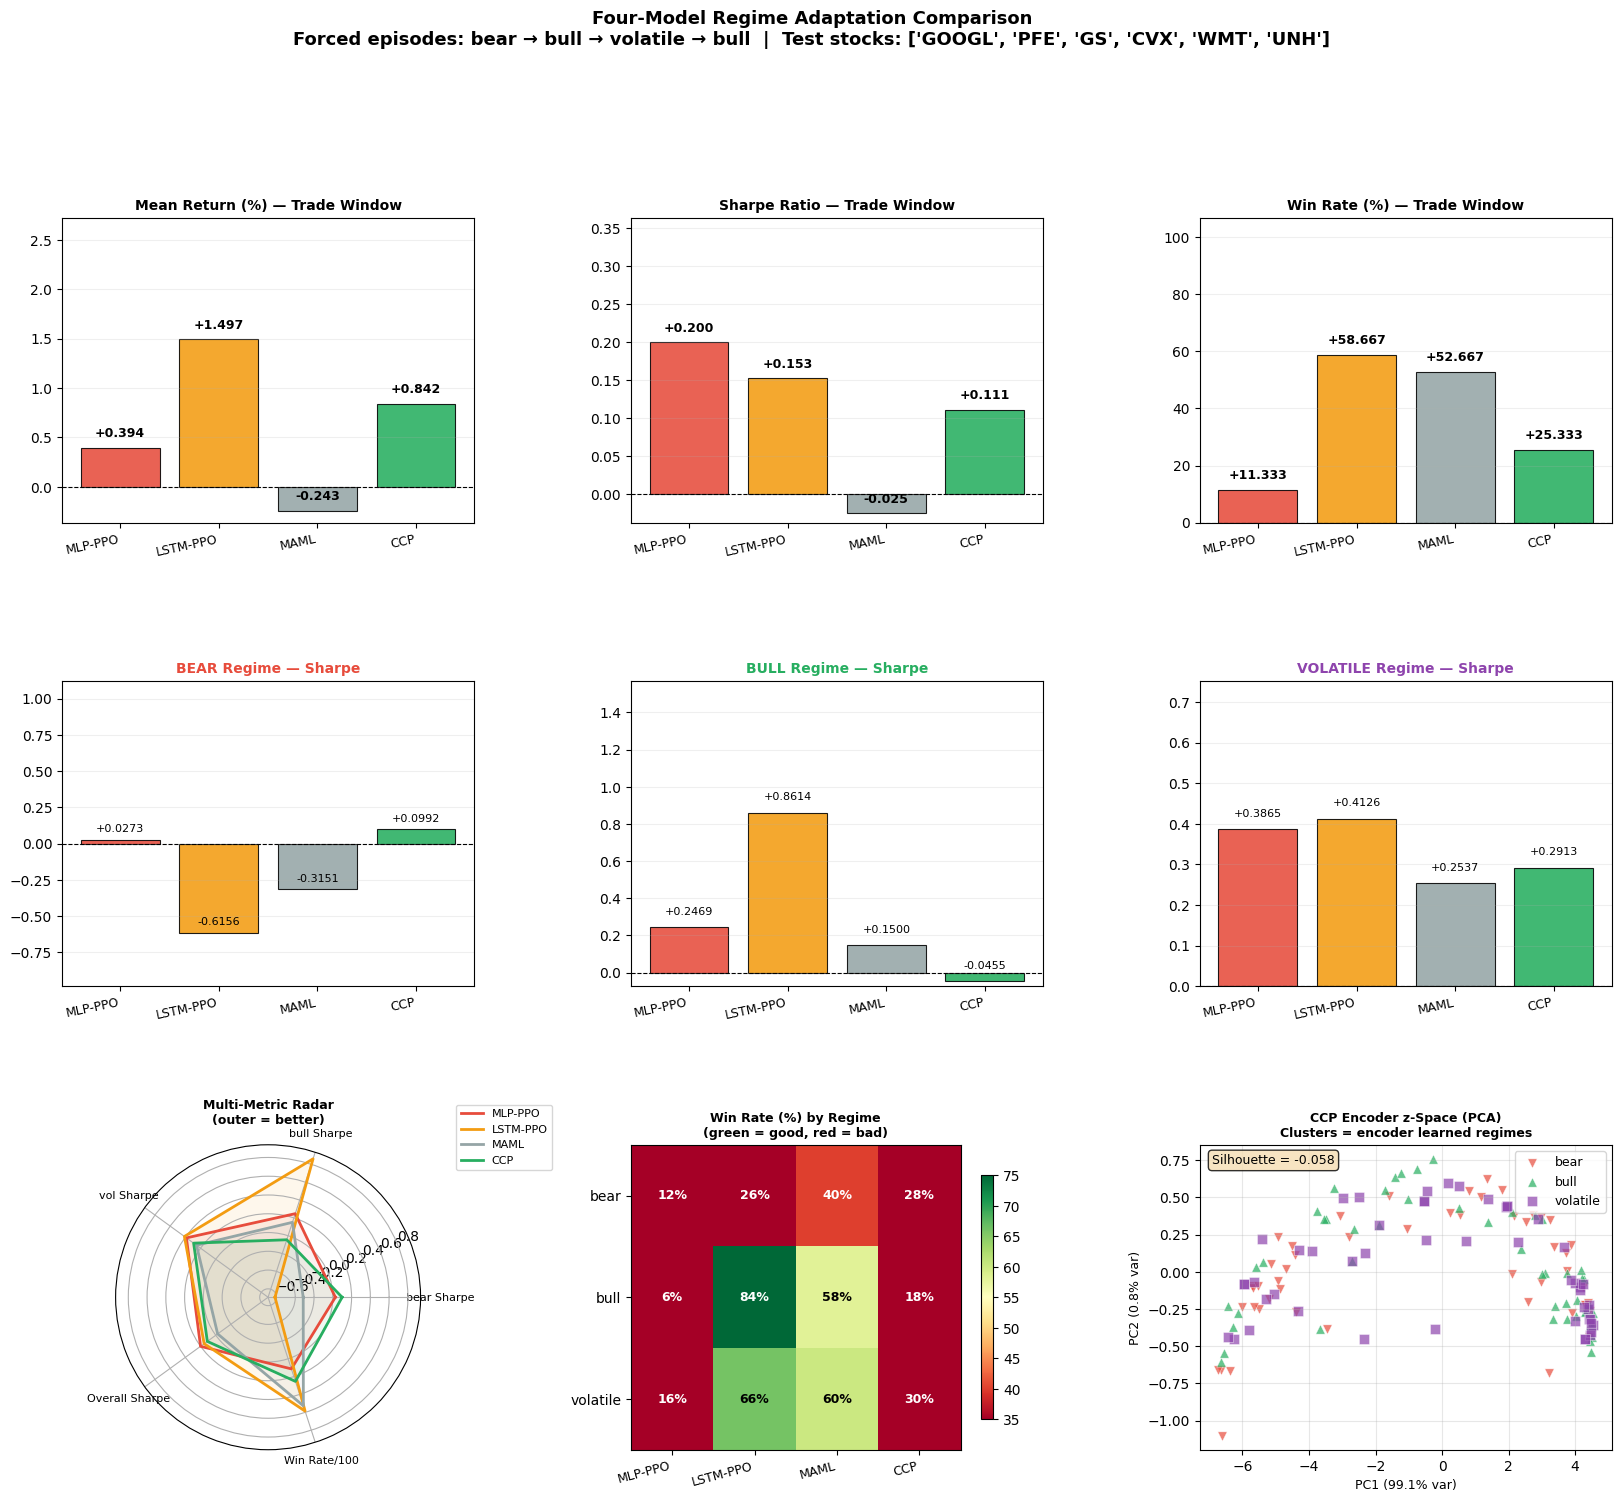

Saved: results/four_model_comparison.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
COLORS  = {'MLP-PPO': '#E74C3C', 'LSTM-PPO': '#F39C12',
           'MAML': '#95A5A6',    'CCP': '#27AE60'}
regimes = ['bear', 'bull', 'volatile']
RC      = {'bear': '#E74C3C', 'bull': '#27AE60', 'volatile': '#8E44AD'}

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)

# Row 1: Overall metrics
for col, (metric, label) in enumerate([
        ('mean_pct', 'Mean Return (%) — Trade Window'),
        ('sharpe',   'Sharpe Ratio — Trade Window'),
        ('win_rate', 'Win Rate (%) — Trade Window')]):
    ax   = fig.add_subplot(gs[0, col])
    vals = [all_results[a][metric] for a in agents]
    bars = ax.bar(agents, vals, color=[COLORS[a] for a in agents],
                  edgecolor='black', linewidth=0.8, alpha=0.88)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xticklabels(agents, rotation=12, ha='right', fontsize=9)
    vspan = max(abs(v) for v in vals) * 1.3 or 0.01
    ax.set_ylim(min(0, min(vals)) * 1.5, vspan * 1.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + vspan * 0.04,
                f'{v:+.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.2, axis='y')

# Row 2: Per-regime Sharpe
for col, rt in enumerate(regimes):
    ax   = fig.add_subplot(gs[1, col])
    vals = [regime_results[rt][a]['sharpe'] for a in agents]
    bars = ax.bar(agents, vals, color=[COLORS[a] for a in agents],
                  edgecolor='black', linewidth=0.8, alpha=0.88)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{rt.upper()} Regime — Sharpe', fontweight='bold',
                 fontsize=10, color=RC[rt])
    ax.set_xticklabels(agents, rotation=12, ha='right', fontsize=9)
    vspan = max(abs(v) for v in vals) * 1.3 or 0.01
    ax.set_ylim(min(0, min(vals)) * 1.6, vspan * 1.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + vspan * 0.05,
                f'{v:+.4f}', ha='center', va='bottom', fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

# Row 3 left: Radar chart
ax7 = fig.add_subplot(gs[2, 0], projection='polar')
metrics_radar = ['bear Sharpe','bull Sharpe','vol Sharpe','Overall Sharpe','Win Rate/100']
N      = len(metrics_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

def _radar_vals(a):
    v = [
        max(-1, min(1, regime_results['bear'][a]['sharpe'])),
        max(-1, min(1, regime_results['bull'][a]['sharpe'])),
        max(-1, min(1, regime_results['volatile'][a]['sharpe'])),
        max(-1, min(1, all_results[a]['sharpe'])),
        all_results[a]['win_rate'] / 100,
    ]
    return v + v[:1]

for a in agents:
    ax7.plot(angles, _radar_vals(a), linewidth=2, color=COLORS[a], label=a)
    ax7.fill(angles, _radar_vals(a), alpha=0.08, color=COLORS[a])
ax7.set_xticks(angles[:-1])
ax7.set_xticklabels(metrics_radar, fontsize=8)
ax7.set_title('Multi-Metric Radar\n(outer = better)', fontweight='bold', fontsize=9, pad=15)
ax7.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=8)

# Row 3 middle: Win-rate heatmap
ax8 = fig.add_subplot(gs[2, 1])
heat_data = np.array([[regime_results[rt][a]['win_rate']
                       for a in agents] for rt in regimes])
im = ax8.imshow(heat_data, cmap='RdYlGn', vmin=35, vmax=75, aspect='auto')
ax8.set_xticks(range(len(agents)))
ax8.set_xticklabels(agents, rotation=15, ha='right', fontsize=9)
ax8.set_yticks(range(len(regimes)))
ax8.set_yticklabels(regimes, fontsize=10)
ax8.set_title('Win Rate (%) by Regime\n(green = good, red = bad)',
              fontweight='bold', fontsize=9)
plt.colorbar(im, ax=ax8, shrink=0.8)
for i in range(len(regimes)):
    for j in range(len(agents)):
        ax8.text(j, i, f"{heat_data[i,j]:.0f}%", ha='center', va='center',
                 fontsize=9, fontweight='bold',
                 color='white' if heat_data[i,j] < 42 or heat_data[i,j] > 68 else 'black')

# Row 3 right: CCP latent space PCA
ax9    = fig.add_subplot(gs[2, 2])
z_data = all_results['CCP']['z_vecs']
if len(z_data) >= 10:
    Z   = np.array([z for z, _ in z_data])
    lbl = [l for _, l in z_data]
    pca = PCA(n_components=2)
    Z2  = pca.fit_transform(StandardScaler().fit_transform(Z))
    ev  = pca.explained_variance_ratio_
    for rt in ['bear', 'bull', 'volatile']:
        mask = [i for i, l in enumerate(lbl) if l == rt]
        if mask:
            ax9.scatter(Z2[mask, 0], Z2[mask, 1], c=RC[rt], label=rt,
                        alpha=0.7, s=45, edgecolors='white', linewidths=0.4,
                        marker={'bear': 'v', 'bull': '^', 'volatile': 's'}[rt])
    if len(set(lbl)) > 1:
        try:
            sil = silhouette_score(Z2, lbl)
            ax9.text(0.03, 0.97, f'Silhouette = {sil:.3f}',
                     transform=ax9.transAxes, fontsize=9, va='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        except Exception:
            pass
    ax9.set_xlabel(f'PC1 ({ev[0]*100:.1f}% var)', fontsize=9)
    ax9.set_ylabel(f'PC2 ({ev[1]*100:.1f}% var)', fontsize=9)
    ax9.legend(fontsize=9); ax9.grid(True, alpha=0.3)
else:
    ax9.text(0.5, 0.5, 'Insufficient z vectors', ha='center',
             va='center', transform=ax9.transAxes)
ax9.set_title('CCP Encoder z-Space (PCA)\nClusters = encoder learned regimes',
              fontweight='bold', fontsize=9)

fig.suptitle(
    'Four-Model Regime Adaptation Comparison\n'
    'Forced episodes: bear → bull → volatile → bull  |  '
    f'Test stocks: {list(test_data.keys())}',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig('results/four_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/four_model_comparison.png")


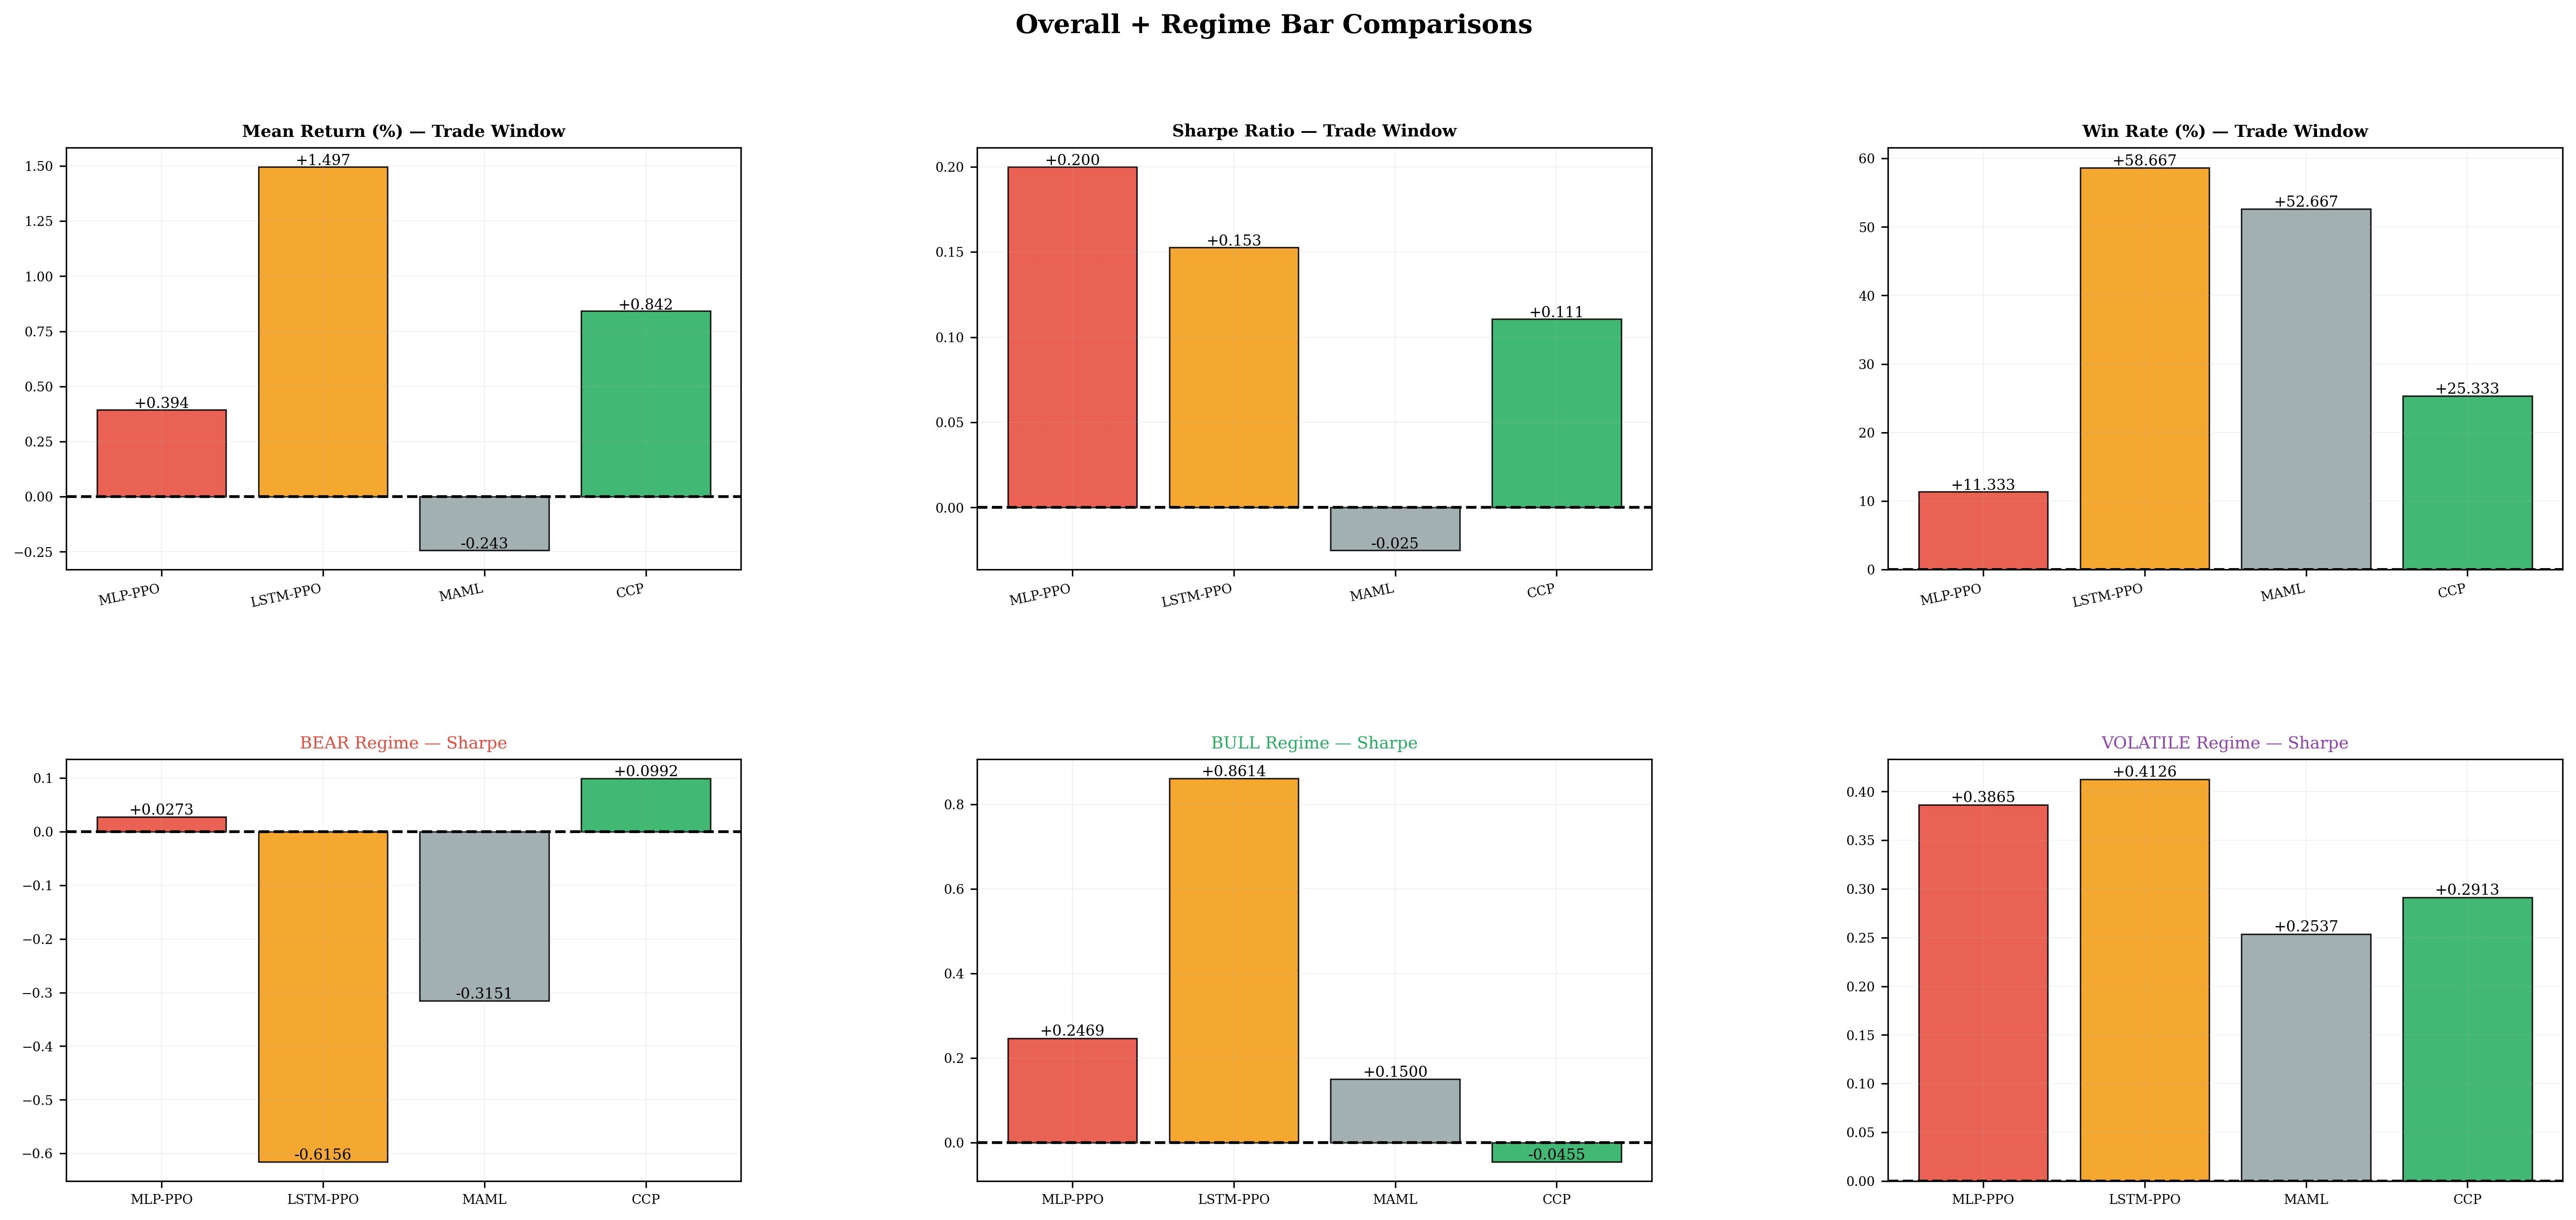

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [28]:
fig = plt.figure(figsize=(24, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# -------- Row 1: Overall metrics --------
for col, (metric, label) in enumerate([
        ('mean_pct', 'Mean Return (%) — Trade Window'),
        ('sharpe',   'Sharpe Ratio — Trade Window'),
        ('win_rate', 'Win Rate (%) — Trade Window')]):

    ax   = fig.add_subplot(gs[0, col])
    vals = [all_results[a][metric] for a in agents]

    bars = ax.bar(agents, vals,
                  color=[COLORS[a] for a in agents],
                  edgecolor='black', linewidth=0.8, alpha=0.88)

    ax.axhline(0, color='black', linestyle='--')
    ax.set_title(label, fontweight='bold')
    ax.set_xticklabels(agents, rotation=12, ha='right')

    vspan = max(abs(v) for v in vals) * 1.3 or 0.01
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+vspan*0.004,
                f'{v:+.3f}', ha='center')

    ax.grid(True, alpha=0.2)

# -------- Row 2: Per-regime Sharpe --------
for col, rt in enumerate(regimes):

    ax   = fig.add_subplot(gs[1, col])
    vals = [regime_results[rt][a]['sharpe'] for a in agents]

    bars = ax.bar(agents, vals,
                  color=[COLORS[a] for a in agents],
                  edgecolor='black', linewidth=0.8, alpha=0.88)

    ax.axhline(0, color='black', linestyle='--')
    ax.set_title(f'{rt.upper()} Regime — Sharpe', color=RC[rt])

    vspan = max(abs(v) for v in vals) * 1.3 or 0.01
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+vspan*0.005,
                f'{v:+.4f}', ha='center')

    ax.grid(True, alpha=0.2)

fig.suptitle("Overall + Regime Bar Comparisons", fontsize=14, fontweight='bold')
plt.show()

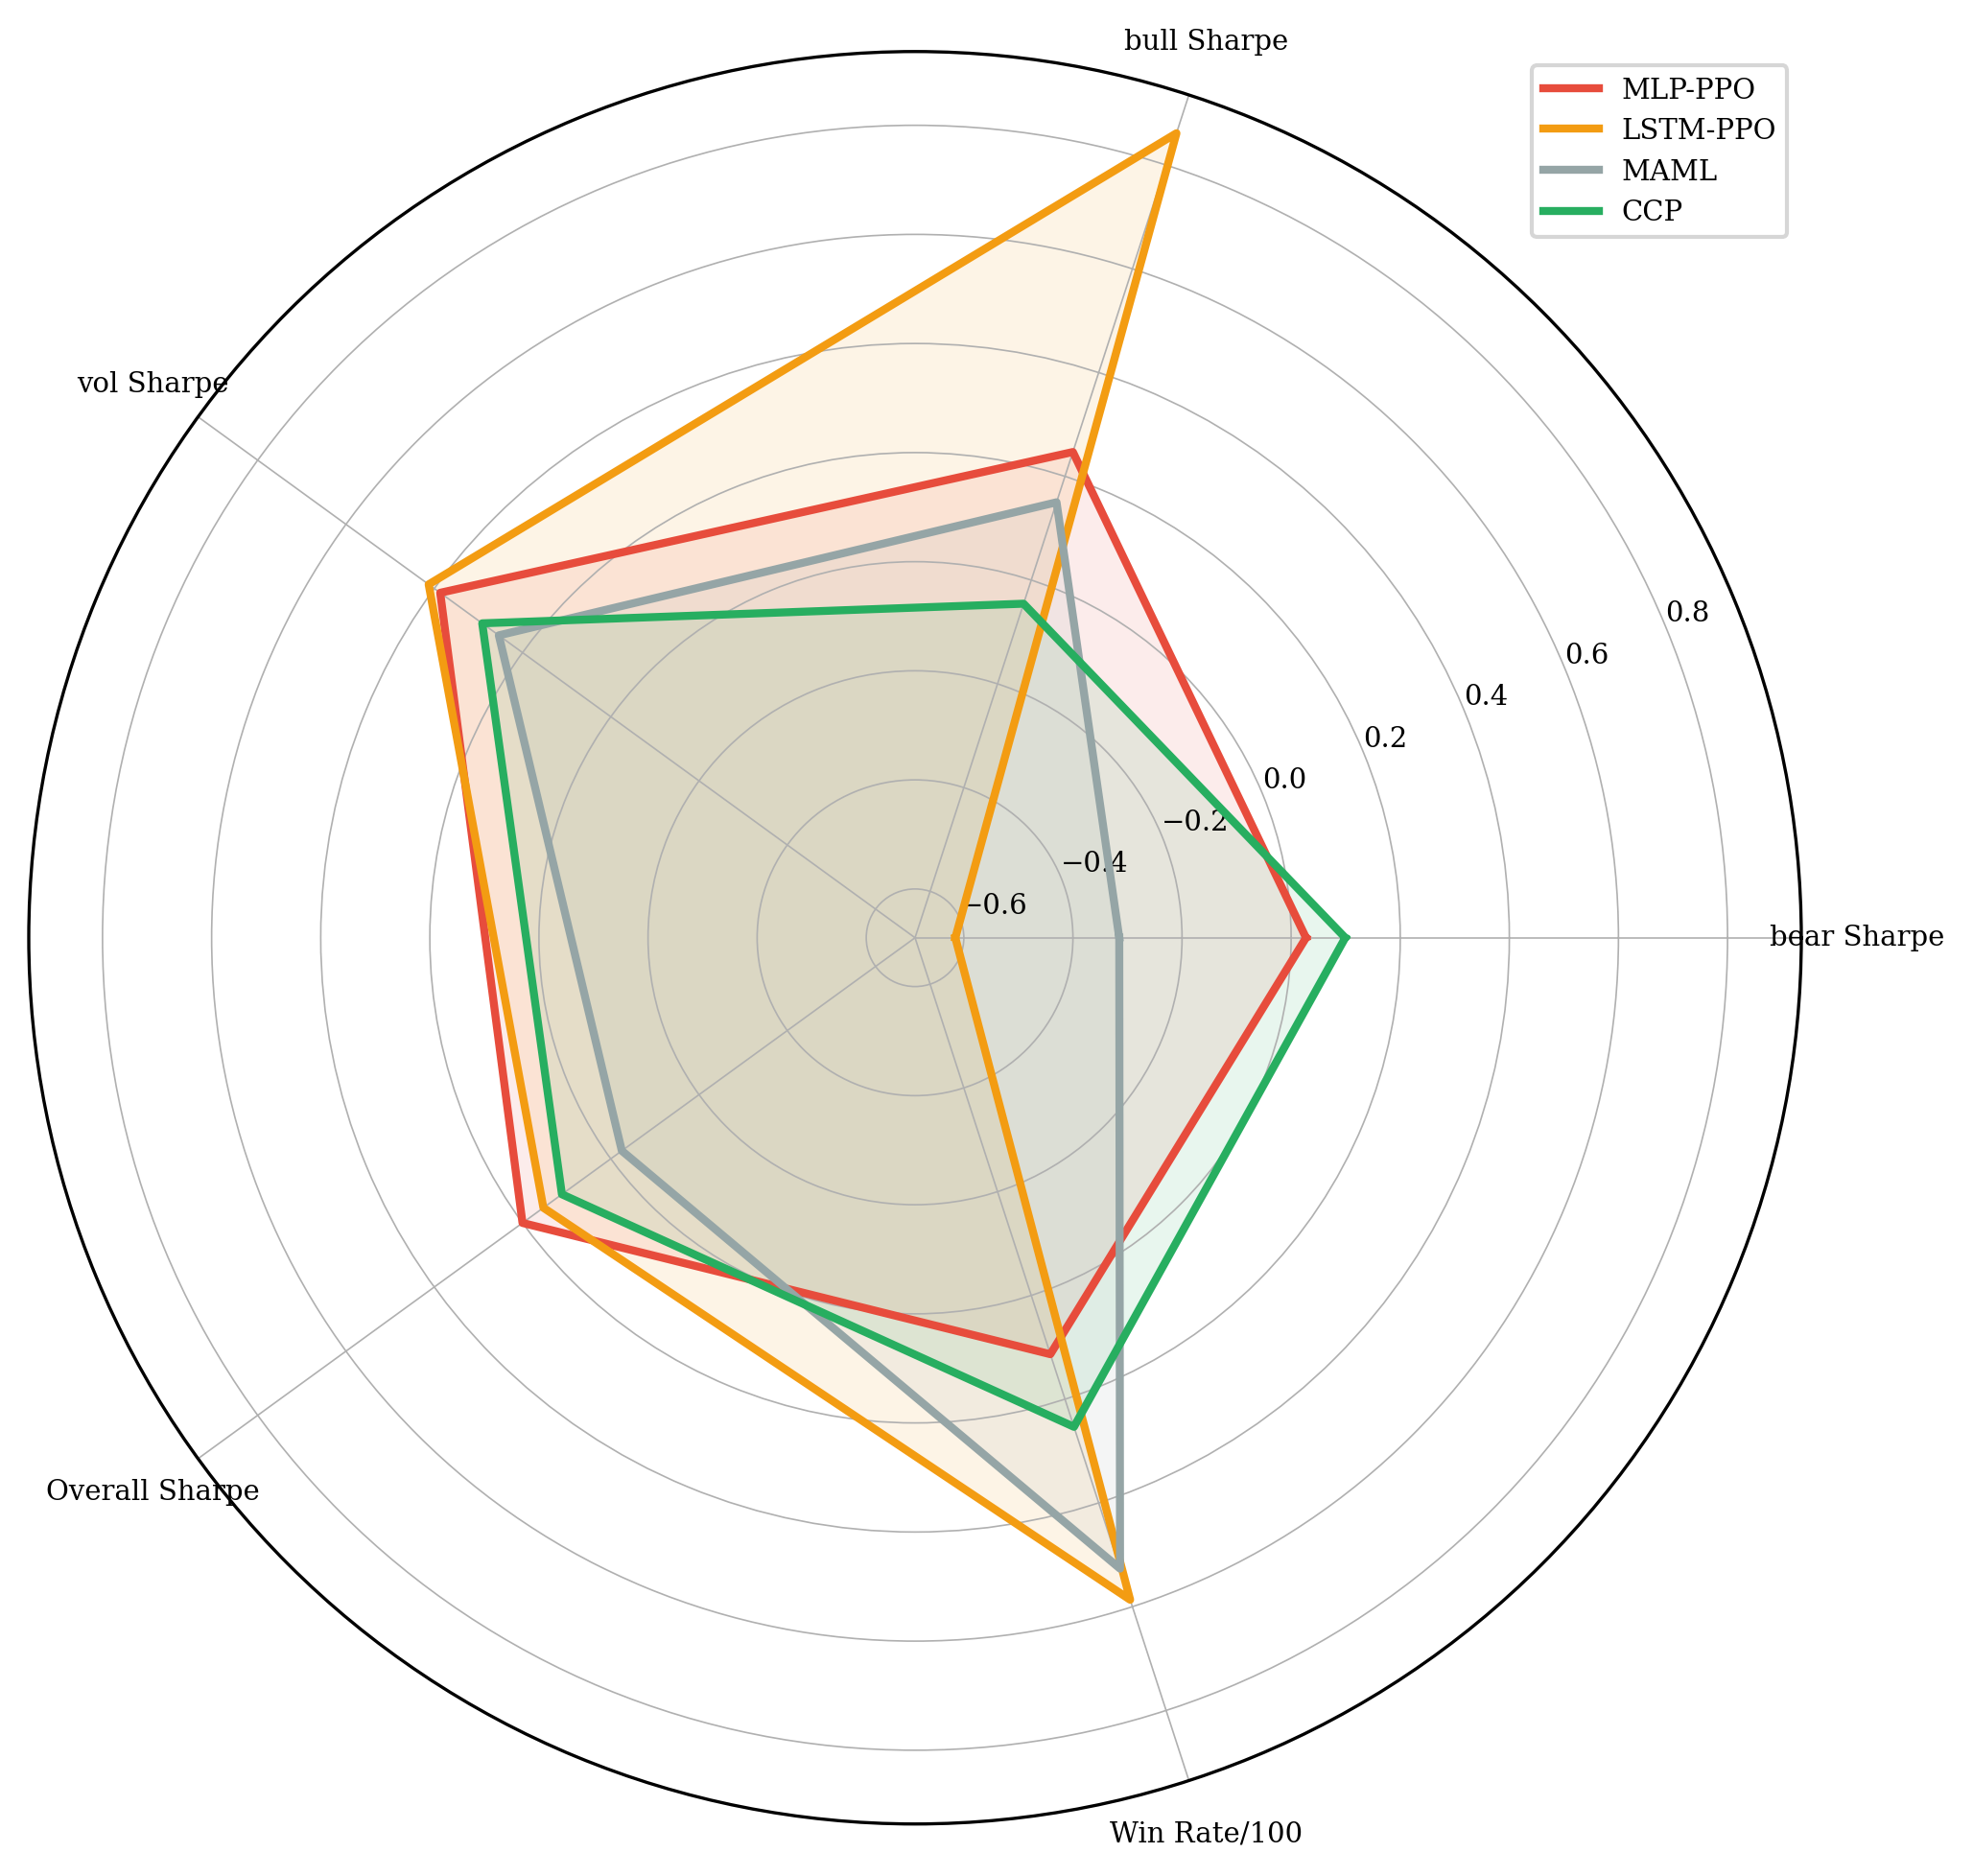

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')

metrics_radar = ['bear Sharpe','bull Sharpe','vol Sharpe','Overall Sharpe','Win Rate/100']
N      = len(metrics_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

def _radar_vals(a):
    v = [
        max(-1, min(1, regime_results['bear'][a]['sharpe'])),
        max(-1, min(1, regime_results['bull'][a]['sharpe'])),
        max(-1, min(1, regime_results['volatile'][a]['sharpe'])),
        max(-1, min(1, all_results[a]['sharpe'])),
        all_results[a]['win_rate'] / 100,
    ]
    return v + v[:1]

for a in agents:
    ax.plot(angles, _radar_vals(a), linewidth=2, color=COLORS[a], label=a)
    ax.fill(angles, _radar_vals(a), alpha=0.1, color=COLORS[a])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar)
ax.legend()
plt.show()

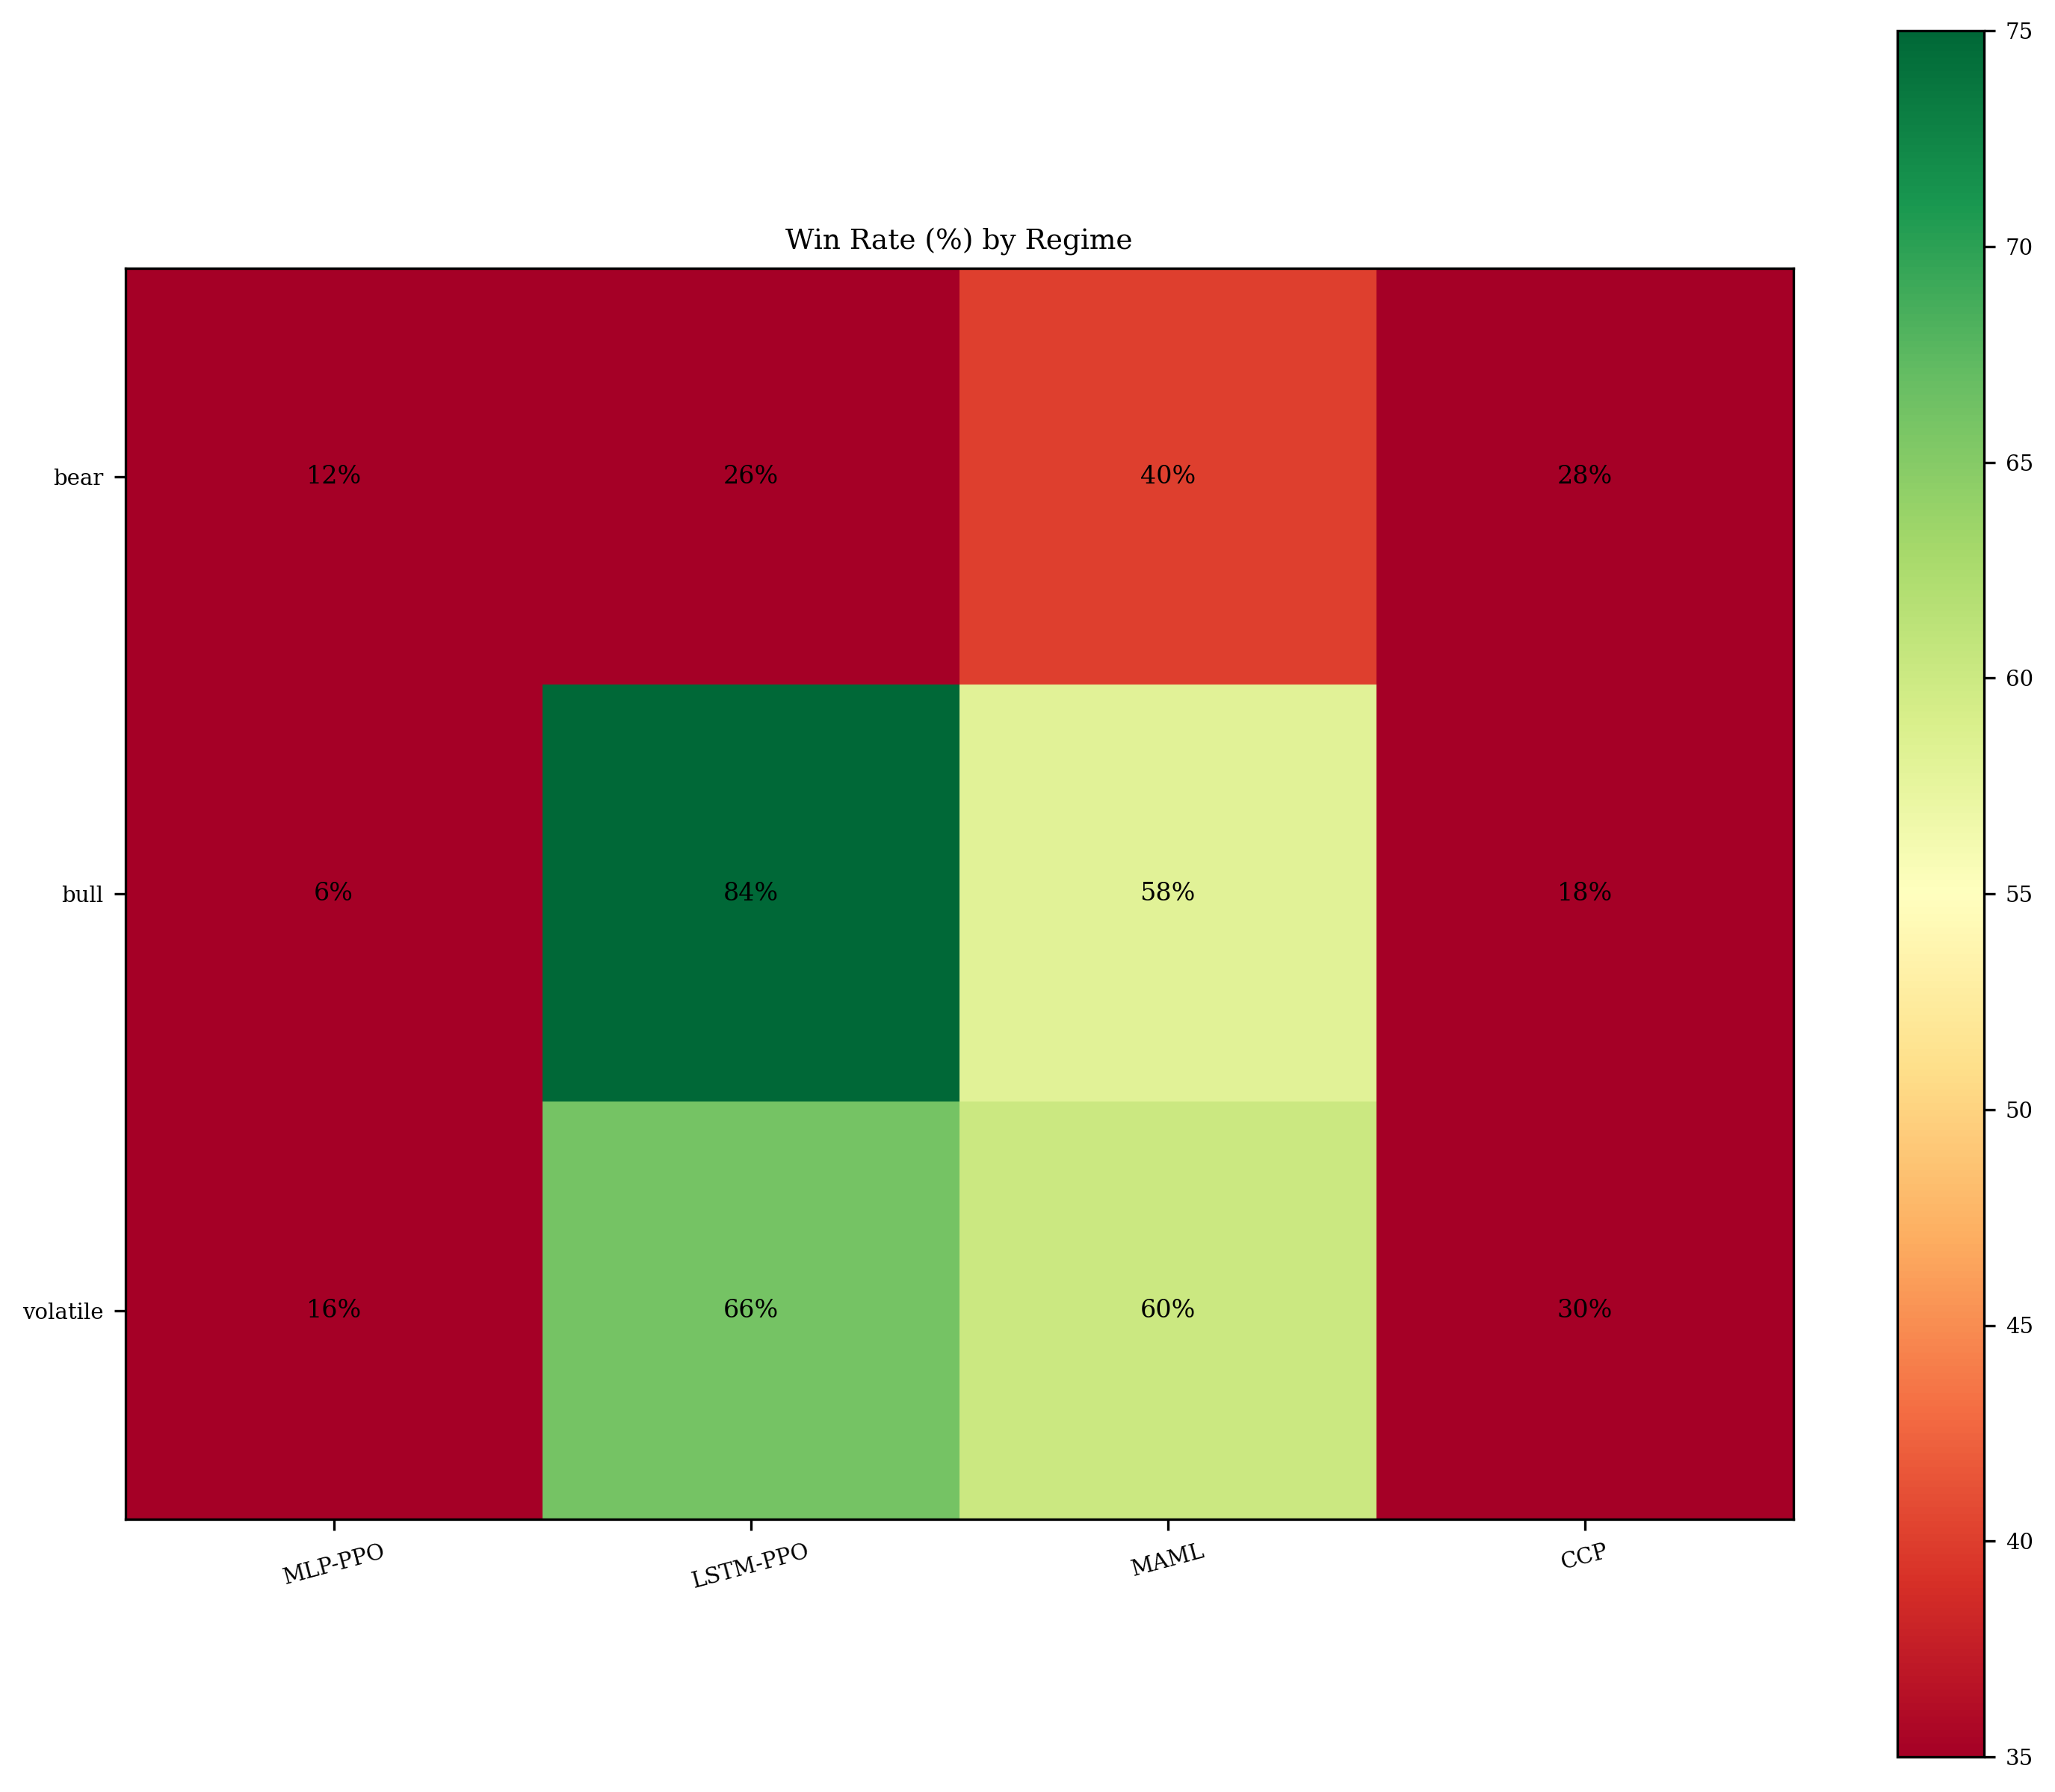

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
fig, ax = plt.subplots(figsize=(12,10))

heat_data = np.array([
    [regime_results[rt][a]['win_rate'] for a in agents]
    for rt in regimes
])

im = ax.imshow(heat_data, cmap='RdYlGn', vmin=35, vmax=75)

ax.set_xticks(range(len(agents)))
ax.set_xticklabels(agents, rotation=15)
ax.set_yticks(range(len(regimes)))
ax.set_yticklabels(regimes)

ax.set_title("Win Rate (%) by Regime")

plt.colorbar(im, ax=ax)

for i in range(len(regimes)):
    for j in range(len(agents)):
        ax.text(j, i, f"{heat_data[i,j]:.0f}%",
                ha='center', va='center')

plt.show()

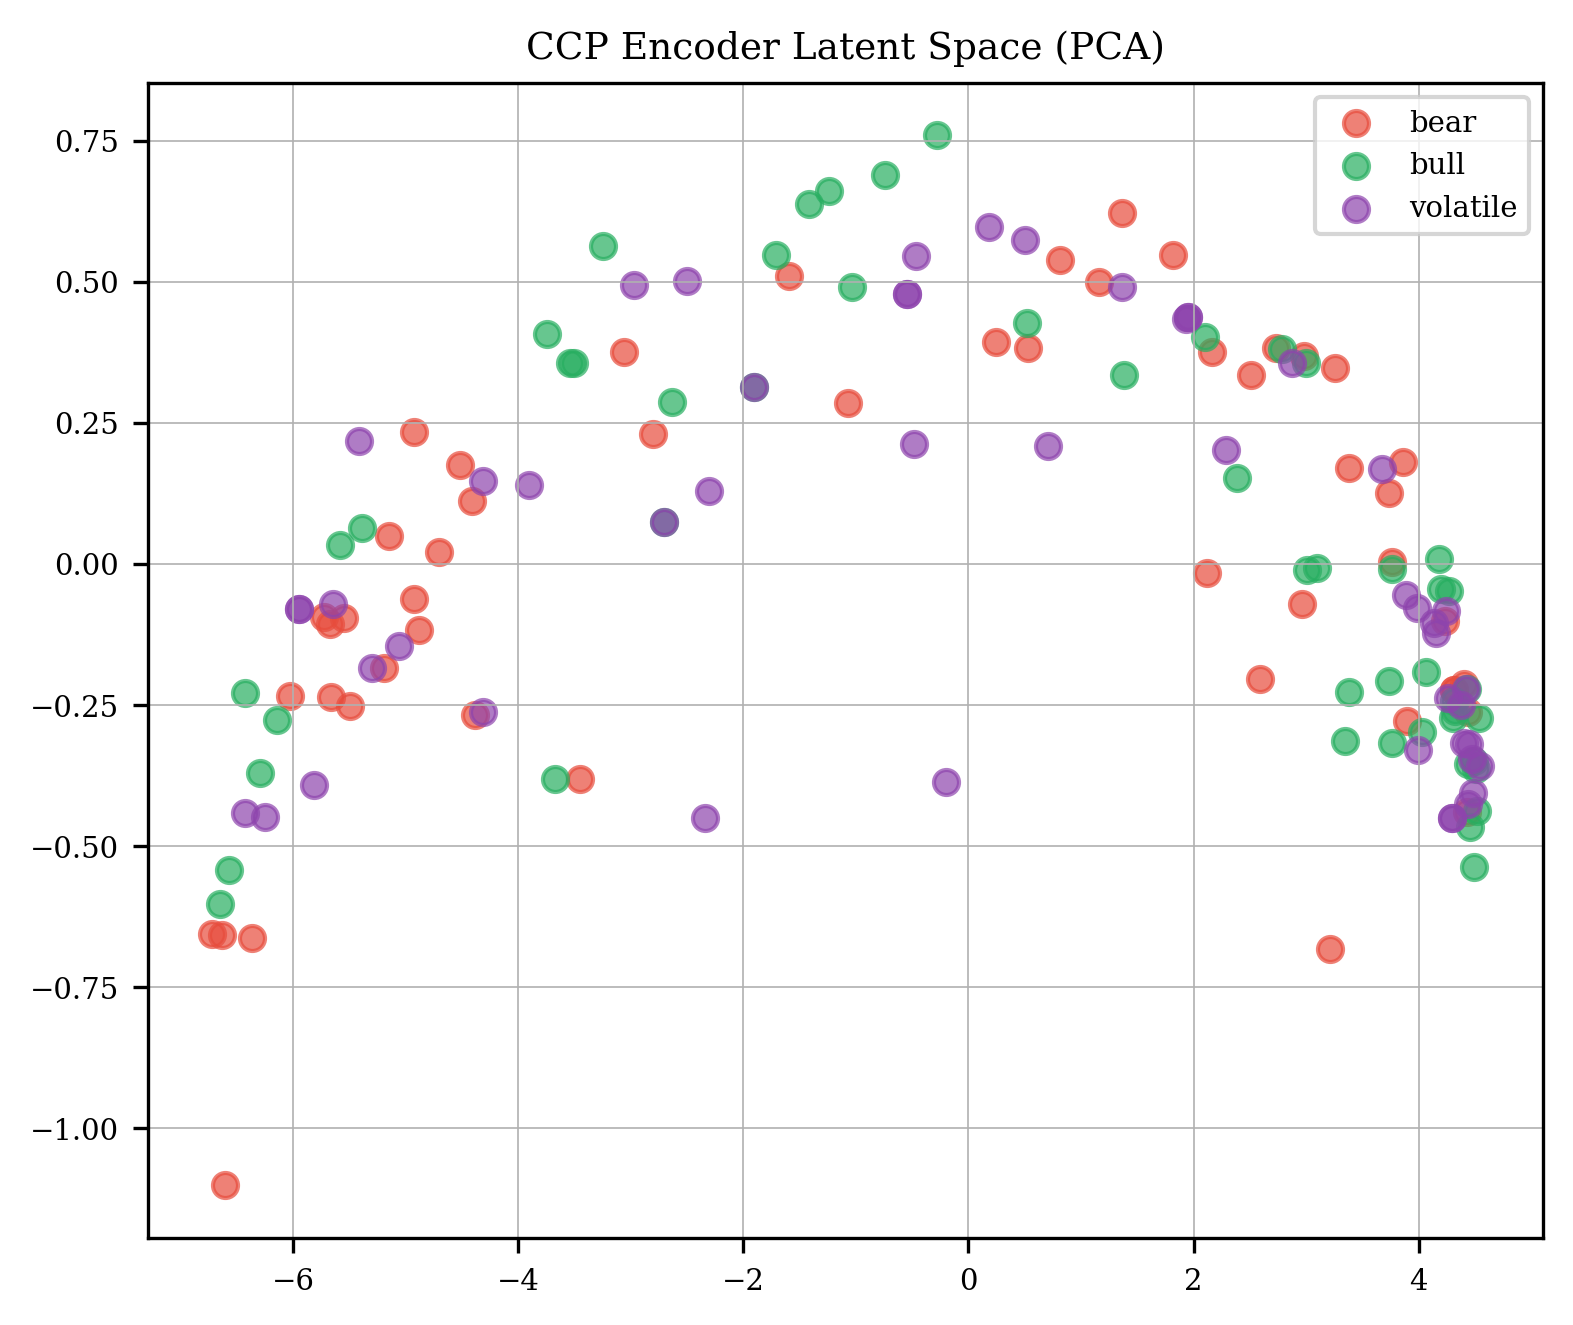

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
fig, ax = plt.subplots(figsize=(6,5))

z_data = all_results['CCP']['z_vecs']

if len(z_data) >= 10:
    Z   = np.array([z for z, _ in z_data])
    lbl = [l for _, l in z_data]

    pca = PCA(n_components=2)
    Z2  = pca.fit_transform(StandardScaler().fit_transform(Z))

    for rt in ['bear','bull','volatile']:
        mask = [i for i,l in enumerate(lbl) if l == rt]
        if mask:
            ax.scatter(Z2[mask,0], Z2[mask,1],
                       c=RC[rt], label=rt, alpha=0.7)

    ax.legend()
    ax.set_title("CCP Encoder Latent Space (PCA)")
    ax.grid(True)

else:
    ax.text(0.5,0.5,"Insufficient z vectors",
            ha='center', transform=ax.transAxes)

plt.show()

In [27]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "grid.linewidth": 0.4,
})